In [14]:
import pandas as pd
import numpy as np
import nltk
import plotly.io as pio
import matplotlib.pyplot as plt
import pickle
import os

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords


os.makedirs('visualisasi', exist_ok=True)
os.makedirs('model', exist_ok=True)

print("Import selesai.")

Import selesai.


In [15]:
df = pd.read_csv('data_BERTOPIC/data_BERTopic.csv')
docs = df['final_bertopic'].tolist()
print(f"Jumlah dokumen: {len(docs)}")
print(f"Contoh dokumen pertama: {docs[0]}")

Jumlah dokumen: 2082
Contoh dokumen pertama: performa mesin maksimal boros bensin pelajari panduan campuran etanol bbm berdasarkan studi fakta performamesin bbmetanol efisiensibahanbakar otomotif ecodriving


In [16]:
nltk_stopwords = stopwords.words('indonesian')
custom_stopwords = [
    'lu', 'gue', 'lo', 'gw', 'kalo', 'aja', 'si', 
    'nya', 'yg', 'dgn', 'utk', 'jg', 'tdk', 'unk',
    'pls', 'bgt', 'banget', 'sih', 'deh', 'dong','as'
]

all_stopwords = nltk_stopwords + custom_stopwords

In [17]:
embedding_model = SentenceTransformer('distiluse-base-multilingual-cased')
print("Embedding model siap.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1046.92it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]   


Embedding model siap.


In [18]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=all_stopwords
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

print("Konfigurasi model selesai.")

Konfigurasi model selesai.


In [19]:
topics, probs = topic_model.fit_transform(docs)
print(f"Training selesai.")
print(f"Jumlah topik terbentuk: {len(topic_model.get_topic_info()) - 1}")

2026-04-13 21:57:27,355 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 66/66 [00:23<00:00,  2.80it/s]
2026-04-13 21:57:50,974 - BERTopic - Embedding - Completed ✓
2026-04-13 21:57:50,975 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 21:57:56,797 - BERTopic - Dimensionality - Completed ✓
2026-04-13 21:57:56,798 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 21:57:56,917 - BERTopic - Cluster - Completed ✓
2026-04-13 21:57:56,920 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 21:57:57,112 - BERTopic - Representation - Completed ✓


Training selesai.
Jumlah topik terbentuk: 26


In [20]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(26))

    Topic  Count                                               Name  \
0      -1    588                        -1_etanol_bbm_bensin_campur   
1       0    320         0_etanol_bahlil_bahlil etanol_pakai etanol   
2       1    218                    1_pertamina_bahan_etanol_energi   
3       2    152                          2_etanol_bbm_rakyat_harga   
4       3    107        3_bensin_campur_bensin campur_campur etanol   
5       4     77                    4_indonesia_etanol_bbm_campuran   
6       5     66                         5_air_etanol_bensin_tangki   
7       6     59        6_dicampur_dicampur etanol_bbm_bbm dicampur   
8       7     51                   7_mesin_efisiensi_korosi_negatif   
9       8     51                 8_swasta_spbu swasta_bbm_pertamina   
10      9     48                       9_biofuel_bio_bobibos_etanol   
11     10     47                10_bbm_etanol bbm_etanol_bbm etanol   
12     11     46                          11_motor_etanol_bbm_pakai   
13    

In [21]:
print("Kata kunci per topik:\n")
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = topic_model.get_topic(topic_id)
        print(f"Topik {topic_id}: {[w for w, _ in words[:10]]}")

Kata kunci per topik:

Topik 0: ['etanol', 'bahlil', 'bahlil etanol', 'pakai etanol', 'pakai', 'etanol bahlil', 'bahenol', 'bau etanol', 'bau', 'bahenol bahlil']
Topik 1: ['pertamina', 'bahan', 'etanol', 'energi', 'bakar', 'bahan bakar', 'bbm', 'spbu', 'indonesia', 'bahlil']
Topik 2: ['etanol', 'bbm', 'rakyat', 'harga', 'campur', 'pemerintah', 'campur etanol', 'bahlil', 'bbm etanol', 'menteri']
Topik 3: ['bensin', 'campur', 'bensin campur', 'campur etanol', 'etanol', 'bahan', 'bensin etanol', 'etanol bensin', 'bahan bakar', 'bakar']
Topik 4: ['indonesia', 'etanol', 'bbm', 'campuran', 'brasil', 'kendaraan', 'campuran etanol', 'etanol bbm', 'pencampuran etanol', 'emisi']
Topik 5: ['air', 'etanol', 'bensin', 'tangki', 'campur', 'bbm', 'air etanol', 'menyerap air', 'menyerap', 'campur etanol']
Topik 6: ['dicampur', 'dicampur etanol', 'bbm', 'bbm dicampur', 'etanol', 'ri dicampur', 'bbm ri', 'etanol dicampur', 'campuran', 'bos']
Topik 7: ['mesin', 'efisiensi', 'korosi', 'negatif', 'emisi', 

C_v Coherence Score: 0.5574


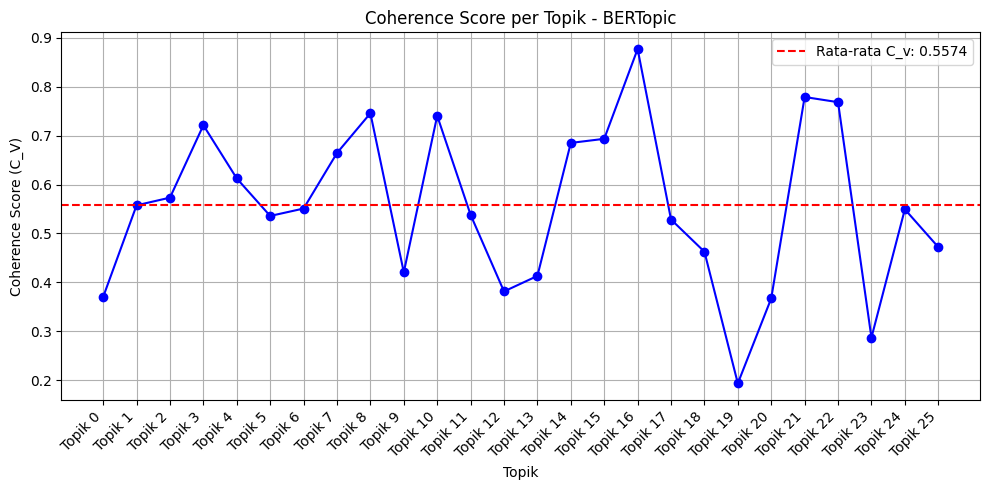

In [22]:
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]

topics_words = []
topic_ids = []
for topic_id in sorted(set(topics)):
    if topic_id != -1:
        words = [word for word, _ in topic_model.get_topic(topic_id)[:10]]
        topics_words.append(words)
        topic_ids.append(topic_id)

if topics_words:
    cv_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    cv_score = cv_model.get_coherence()
    cv_per_topic = cv_model.get_coherence_per_topic()
    
    print(f"C_v Coherence Score: {cv_score:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(
        [f"Topik {t}" for t in topic_ids],
        cv_per_topic,
        marker='o',
        color='b'
    )
    plt.axhline(y=cv_score, color='red', linestyle='--', label=f'Rata-rata C_v: {cv_score:.4f}')
    plt.xlabel('Topik')
    plt.ylabel('Coherence Score (C_V)')
    plt.title('Coherence Score per Topik - BERTopic')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('visualisasi/coherence_score_bertopic2.png', dpi=150)
    plt.show()
else:
    print("Tidak ada topik yang terbentuk.")

In [23]:
def topic_diversity(topic_model, topics, top_n=10):
    topics_words = []
    for topic_id in set(topics):
        if topic_id != -1:
            words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
            topics_words.append(words)

    all_words = [word for topic in topics_words for word in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words) if all_words else 0
    return diversity

td_score = topic_diversity(topic_model, topics)
print(f"Topic Diversity: {td_score:.4f}")

Topic Diversity: 0.6462


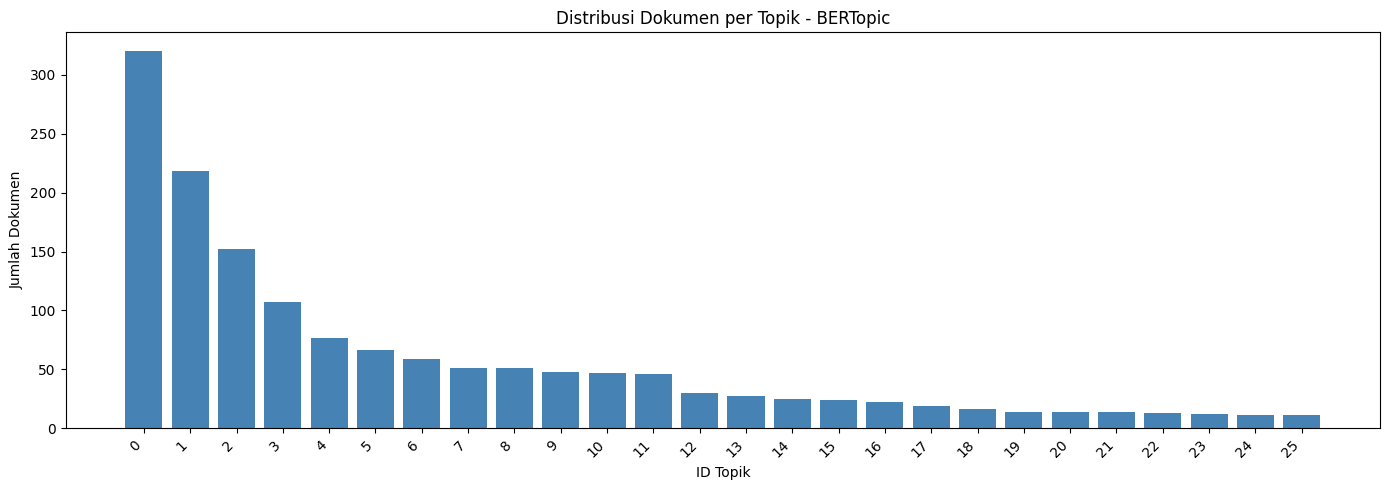

Visualisasi selesai.


In [24]:
# 1. Topic-Word Scores
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10)
pio.write_html(fig_barchart, 'visualisasi/barchart_topik2.html') 

# 2. Intertopic Distance Map
fig_topics = topic_model.visualize_topics()
pio.write_html(fig_topics, 'visualisasi/intertopic_distance2.html') 

# 3. Distribusi dokumen per topik
topic_info = topic_model.get_topic_info()
topic_info_clean = topic_info[topic_info['Topic'] != -1]

plt.figure(figsize=(14, 5))
plt.bar(
    topic_info_clean['Topic'].astype(str),
    topic_info_clean['Count'],
    color='steelblue'
)
plt.xlabel('ID Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Dokumen per Topik - BERTopic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualisasi/distribusi_dokumen_per_topik2.png', dpi=150)  
plt.show()

print("Visualisasi selesai.")

In [25]:
import os
os.makedirs('model', exist_ok=True)

# Simpan tanpa embedding model (lebih aman)
topic_model.save(
    "model/bertopic_model",
    serialization="safetensors",
    save_embedding_model=False,
    save_ctfidf=True
)

# Load kembali dengan embedding model didefinisikan ulang
loaded_model = BERTopic.load(
    "model/bertopic_model",
    embedding_model=embedding_model
)

print("Model berhasil disimpan dan diverifikasi.")

2026-04-13 21:58:08,160 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Model berhasil disimpan dan diverifikasi.
